数据预处理

In [ ]:
# 导入所需库
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             precision_score, recall_score, f1_score)

# 设置随机种子，确保结果可复现
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 配置文件路径（请根据实际情况修改）
DATA_PATH = "../../processed/final_dataset_v2_plus.csv"   # 相对于 baseline 文件夹
OUTPUT_DIR = "results"

# 回测参数
TRANSACTION_FEE = 0.001          # 0.1% 手续费
PRED_THRESHOLD = 0.5              # 初始预测阈值，后续将用验证集优化
TRAIN_TEST_SPLIT = 0.7            # 训练集比例
VAL_SPLIT = 0.2                   # 在训练集内部进一步划分验证集比例，用于阈值/超参验证

# 创建输出目录
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("配置完成，输出目录：", OUTPUT_DIR)

配置完成，输出目录： results


数据加载与初步检查

In [73]:
# 加载数据
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

# 检查缺失值
if df.isnull().sum().sum() > 0:
    print("警告：数据中存在缺失值，将删除包含缺失值的行。")
    df.dropna(inplace=True)

# 查看数据概览
print(f"数据时间范围: {df['date'].min()} 至 {df['date'].max()}")
print(f"总样本数: {len(df)}")
print(f"特征列数: {len(df.columns) - 2}")  # 减去 date 和 target
print(f"正例比例 (target=1): {df['target'].mean():.4f}")

# 显示前几行
df.head()

数据时间范围: 2018-02-02 00:00:00 至 2026-03-17 00:00:00
总样本数: 2966
特征列数: 25
正例比例 (target=1): 0.5094


,date,open,high,low,close,volume,quote_volume,trade_count,ret_1d,ret_3d,...,hash_rate,fees,vix,dxy_proxy,fear_greed_index,difficulty,sp500_return,active_addresses_change,fees_per_tx,difficulty_change
0,2018-02-02,10285.10,10335.00,8750.99,9224.52,33564.764311,3.176363e+08,316020.0,-0.103118,-0.180116,...,2.070395e+07,214.027545,13.47,106.4877,30.0,2.603077e+12,-0.000648,0.229578,0.000831,0.0
1,2018-02-03,9224.52,9250.00,8010.02,8873.03,49971.626975,4.342365e+08,453411.0,-0.038104,-0.133282,...,2.173915e+07,274.362582,17.31,107.1151,15.0,2.603077e+12,-0.021209,-0.068214,0.001163,0.0
2,2018-02-04,8873.03,9473.01,8229.00,9199.96,28725.000735,2.568347e+08,327519.0,0.036845,-0.105506,...,2.044515e+07,146.927769,17.31,107.1151,40.0,2.603077e+12,0.000000,-0.208640,0.000754,0.0
3,2018-02-05,9199.96,9368.00,7930.00,8184.81,32014.308449,2.749123e+08,356134.0,-0.110343,-0.112712,...,2.303314e+07,111.316698,17.31,107.1151,24.0,2.603077e+12,0.000000,-0.090560,0.000641,0.0
4,2018-02-06,8179.99,8382.80,6625.00,6939.99,63403.182579,4.711662e+08,533510.0,-0.152089,-0.217856,...,2.393894e+07,173.767502,37.32,107.3300,11.0,2.603077e+12,-0.040979,0.226519,0.000803,0.0


特征与标签分离，时间序列划分

In [ ]:
# 特征列（排除 date 和 target）
feature_cols = [col for col in df.columns if col not in ['date', 'target']]
X = df[feature_cols]
y = df['target']

# 按时间顺序划分训练集和测试集
split_idx = int(len(df) * TRAIN_TEST_SPLIT)
# 完整训练集（用于训练随机森林等）
X_train_full = X.iloc[:split_idx]
y_train_full = y.iloc[:split_idx]
# 在完整训练集内部再划分内部训练/验证集（用于阈值/超参选择，避免使用测试集）
inner_split_idx = int(split_idx * (1 - VAL_SPLIT))
X_train_inner = X_train_full.iloc[:inner_split_idx]
X_val = X_train_full.iloc[inner_split_idx:split_idx]
y_train_inner = y_train_full.iloc[:inner_split_idx]
y_val = y_train_full.iloc[inner_split_idx:split_idx]
# 测试集
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]
# 日期索引
train_dates = df.iloc[:inner_split_idx]['date'].reset_index(drop=True)
val_dates = df.iloc[inner_split_idx:split_idx]['date'].reset_index(drop=True)
test_dates = df.iloc[split_idx:]['date'].reset_index(drop=True)

# 为兼容旧变量名，保留 X_train/y_train 指向完整训练集
X_train = X_train_full
y_train = y_train_full

print(f"完整训练集样本数: {len(X_train_full)}")
print(f"内部训练集样本数: {len(X_train_inner)}")
print(f"验证集样本数: {len(X_val)}")
print(f"测试集样本数: {len(X_test)}")
print(f"完整训练集(含验证)日期范围: {df['date'].iloc[0]} 至 {df['date'].iloc[split_idx-1]}")
print(f"测试集日期范围: {df['date'].iloc[split_idx]} 至 {df['date'].iloc[-1]}")

训练集样本数: 2076
测试集样本数: 890
训练集日期范围: 2018-02-02 00:00:00 至 2023-10-09 00:00:00
测试集日期范围: 2023-10-10 00:00:00 至 2026-03-17 00:00:00


特征标准化（仅用于逻辑回归）

In [ ]:
# 标准化：对内部训练集拟合，转换内部训练/验证/测试集
scaler = StandardScaler()
X_train_inner_scaled = scaler.fit_transform(X_train_inner)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("特征标准化完成（基于内部训练集）。")

特征标准化完成。


逻辑回归（L1正则）训练与评估

In [ ]:
# 使用内部训练集进行时间序列交叉验证选择最佳 C 值（在内部训练集上训练）
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
lr = LogisticRegression(penalty='l1', solver='saga',
                        max_iter=1000, random_state=RANDOM_SEED)

grid_lr = GridSearchCV(lr, param_grid, cv=tscv,
                       scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_inner_scaled, y_train_inner)

best_lr = grid_lr.best_estimator_
# 在验证集上得到预测概率，用于阈值优化（以夏普比最大化为目标）
y_val_proba_lr = best_lr.predict_proba(X_val_scaled)[:, 1]
# 对齐验证集收益（用 ret_1d 的 t+1 日收益来评估 t 日信号）
val_returns = df['ret_1d'].iloc[inner_split_idx:split_idx].shift(-1).iloc[:-1].values
y_val_proba_lr_aligned = y_val_proba_lr[:-1]
val_dates_aligned = val_dates.iloc[:-1]
assert len(y_val_proba_lr_aligned) == len(val_returns), '验证集概率与收益率长度不匹配！'

# 在验证集上扫描阈值以最大化夏普比
best_sharpe = -float('inf')
best_thr = PRED_THRESHOLD
for thr in np.linspace(0.1, 0.9, 81):
    signals_val = pd.Series((y_val_proba_lr_aligned > thr).astype(int), index=val_dates_aligned)
    position_changes_val = signals_val.diff().fillna(signals_val.iloc[0])
    trades_val = position_changes_val.abs()
    strat_ret_val = signals_val.shift(1).fillna(0) * val_returns - trades_val * TRANSACTION_FEE
    if strat_ret_val.std() == 0 or np.isnan(strat_ret_val.std()):
        sharpe_val = -float('inf')
    else:
        sharpe_val = np.sqrt(252) * strat_ret_val.mean() / strat_ret_val.std()
    if sharpe_val > best_sharpe:
        best_sharpe = sharpe_val
        best_thr = thr

PRED_THRESHOLD = best_thr
print(f"验证集最优阈值 (按夏普最大化): {PRED_THRESHOLD:.3f}, 验证夏普: {best_sharpe:.4f}")

# 在测试集上使用选定阈值评估并保存概率/预测
y_pred_proba_lr = best_lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_pred_proba_lr > PRED_THRESHOLD).astype(int)

# 计算分类指标（基于所选阈值）
metrics_lr = {
    'model': 'LogisticRegression_L1',
    'roc_auc': roc_auc_score(y_test, y_pred_proba_lr),
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr)
}

print(f"最佳 C 值: {grid_lr.best_params_['C']}")
print("逻辑回归分类指标（基于验证集最优阈值）：")
for k, v in metrics_lr.items():
    if k != 'model':
        print(f"  {k}: {v:.4f}")

最佳 C 值: 0.1
逻辑回归分类指标：
  roc_auc: 0.5355
  accuracy: 0.4865
  precision: 0.6667
  recall: 0.0044
  f1: 0.0087


随机森林训练与评估

In [77]:
# 训练随机森林（不需要标准化）
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                            random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)

metrics_rf = {
    'model': 'RandomForest',
    'roc_auc': roc_auc_score(y_test, y_pred_proba_rf),
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf)
}

print("随机森林分类指标：")
for k, v in metrics_rf.items():
    if k != 'model':
        print(f"  {k}: {v:.4f}")

随机森林分类指标：
  roc_auc: 0.5132
  accuracy: 0.4865
  precision: 0.5185
  recall: 0.0306
  f1: 0.0577


保存分类指标到 CSV

In [78]:
# 合并两个模型的指标并保存
metrics_df = pd.DataFrame([metrics_lr, metrics_rf])
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'baseline_metrics.csv'), index=False)
print(f"分类指标已保存至 {OUTPUT_DIR}/baseline_metrics.csv")

# 显示表格
metrics_df

分类指标已保存至 results/baseline_metrics.csv


,model,roc_auc,accuracy,precision,recall,f1
0,LogisticRegression_L1,0.535490,0.486517,0.666667,0.004367,0.008677
1,RandomForest,0.513222,0.486517,0.518519,0.030568,0.057732


金融回测（使用逻辑回归预测）

In [79]:
# ==================== 金融回测（使用 ret_1d 列）====================

# 使用数据集中的 ret_1d 作为每日收益率（t日收益率 = (close_t - close_{t-1}) / close_{t-1}）
# 我们需要 t+1 日的收益率来评估 t 日收盘时的交易信号
test_returns = df['ret_1d'].iloc[split_idx:].shift(-1).iloc[:-1].values
# 对应的预测概率（去掉最后一个无法计算收益率的样本）
y_pred_proba_lr_aligned = y_pred_proba_lr[:-1]
test_dates_aligned = test_dates.iloc[:-1]

# 打印长度进行调试
print(f"测试集样本数 (N): {len(y_pred_proba_lr)}")
print(f"对齐后预测概率长度: {len(y_pred_proba_lr_aligned)}")
print(f"test_returns 长度: {len(test_returns)}")
print(f"test_dates_aligned 长度: {len(test_dates_aligned)}")

# 确保长度一致
assert len(y_pred_proba_lr_aligned) == len(test_returns), "预测概率与收益率长度不匹配！"

# 生成交易信号，并转换为 Pandas Series（以便使用 .diff() 和 .shift()）
signals = pd.Series(
    (y_pred_proba_lr_aligned > PRED_THRESHOLD).astype(int),
    index=test_dates_aligned
)

# 计算持仓变化，用于交易次数
position_changes = signals.diff().fillna(signals.iloc[0])
trades = position_changes.abs()  # 每次变化（0->1 或 1->0）视为一次交易

# 策略日收益率 = 信号 * 市场收益率 - 交易次数 * 手续费
strategy_returns = signals.shift(1).fillna(0) * test_returns - trades * TRANSACTION_FEE

# 计算累计收益
cumulative_strategy = (1 + strategy_returns).cumprod()
cumulative_buy_hold = (1 + pd.Series(test_returns, index=test_dates_aligned)).cumprod()

# 计算回测指标
sharpe = np.sqrt(252) * strategy_returns.mean() / strategy_returns.std()
total_return = cumulative_strategy.iloc[-1] - 1
rolling_max = cumulative_strategy.expanding().max()
drawdown = (cumulative_strategy - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# 输出结果
print("\n回测结果（逻辑回归策略）：")
print(f"  夏普比率 (年化): {sharpe:.4f}")
print(f"  总收益率: {total_return:.4f}")
print(f"  最大回撤: {max_drawdown:.4f}")
print(f"  平均日收益率: {strategy_returns.mean():.6f}")
print(f"  日收益率标准差: {strategy_returns.std():.6f}")

测试集样本数 (N): 890
对齐后预测概率长度: 889
test_returns 长度: 889
test_dates_aligned 长度: 889

回测结果（逻辑回归策略）：
  夏普比率 (年化): -0.3732
  总收益率: -0.0047
  最大回撤: -0.0083
  平均日收益率: -0.000005
  日收益率标准差: 0.000226


保存回测指标与绘制累计收益曲线

回测指标已保存至 results/backtest_results.csv


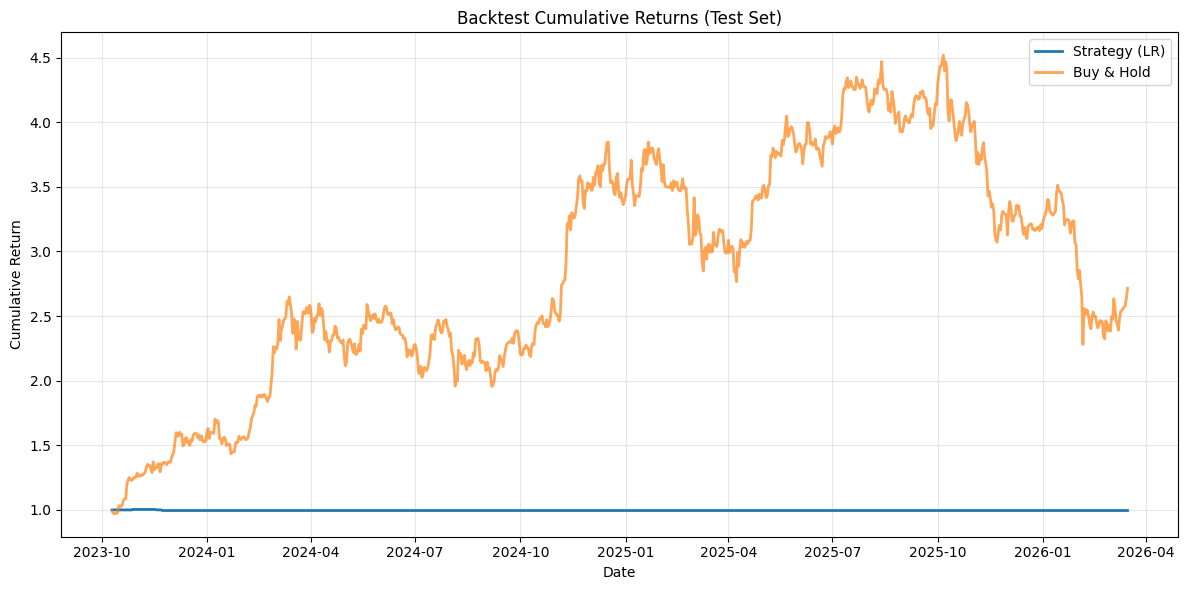

累计收益曲线图已保存至 results/backtest_results.png


In [80]:
# 保存回测指标到 CSV
backtest_results = pd.DataFrame([{
    'strategy': 'LogisticRegression_L1',
    'sharpe_ratio': sharpe,
    'max_drawdown': max_drawdown,
    'total_return': total_return,
    'avg_daily_return': strategy_returns.mean(),
    'std_daily_return': strategy_returns.std()
}])
backtest_results.to_csv(os.path.join(OUTPUT_DIR, 'backtest_results.csv'), index=False)
print(f"回测指标已保存至 {OUTPUT_DIR}/backtest_results.csv")

# 绘制累计收益曲线
plt.figure(figsize=(12, 6))
plt.plot(test_dates_aligned, cumulative_strategy, label='Strategy (LR)', linewidth=2)
plt.plot(test_dates_aligned, cumulative_buy_hold, label='Buy & Hold', linewidth=2, alpha=0.7)
plt.title('Backtest Cumulative Returns (Test Set)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'backtest_results.png'), dpi=150)
plt.show()
print(f"累计收益曲线图已保存至 {OUTPUT_DIR}/backtest_results.png")

随机森林特征重要性

随机森林特征重要性 Top 15:
                feature  importance
                 ret_1d    0.064956
                 ret_3d    0.051398
                   fees    0.050180
active_addresses_change    0.048417
          volume_change    0.045913
               tx_count    0.043978
            fees_per_tx    0.043087
          volatility_7d    0.042810
        high_low_spread    0.042607
          ma_ratio_7_30    0.041803
                 volume    0.041152
              hash_rate    0.039624
                  close    0.039619
            trade_count    0.039300
           sp500_return    0.038509


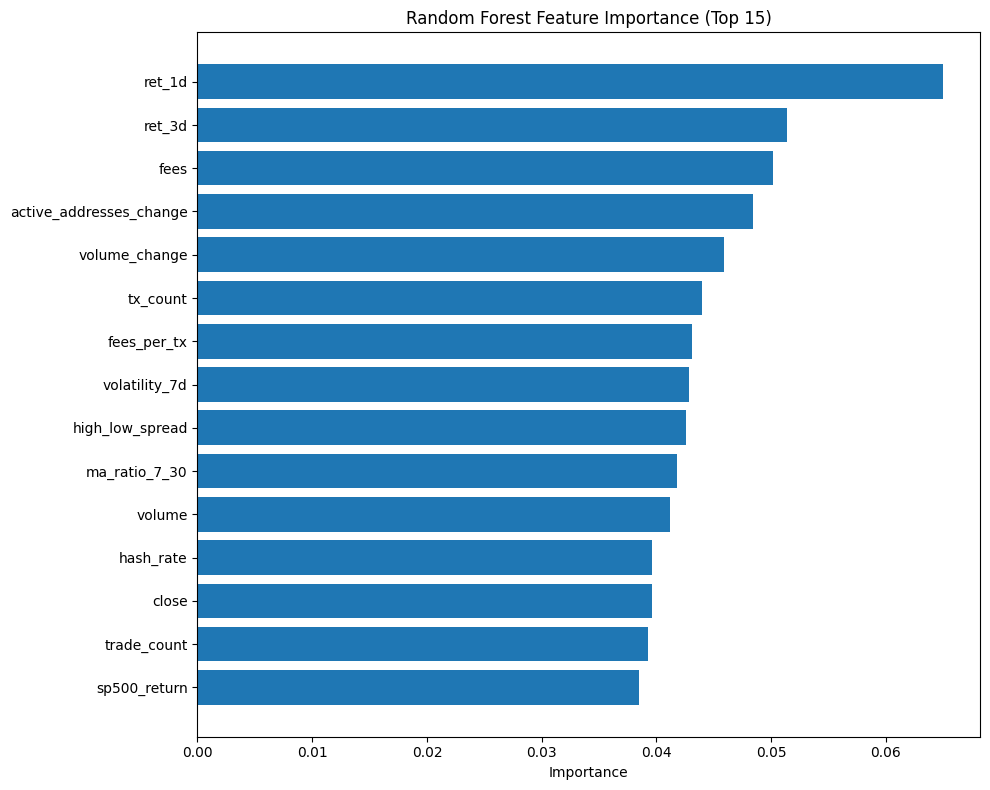

特征重要性图已保存至 results/rf_feature_importance.png


In [81]:
# 计算特征重要性并排序
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

# 显示前15个重要特征
print("随机森林特征重要性 Top 15:")
print(feature_importance.head(15).to_string(index=False))

# 绘制条形图
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance (Top 15)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_feature_importance.png'), dpi=150)
plt.show()
print(f"特征重要性图已保存至 {OUTPUT_DIR}/rf_feature_importance.png")